# Data cleaning for sentiment analysis: Amazon consumer reviews

**Dataset:** Datafiniti *Consumer Reviews of Amazon Products* (`1429_1.csv`)
**Goal of this notebook:** turn the raw file into a clean table with one review text and one sentiment label per row, ready for the TF-IDF baseline and the transformer fine-tuning.

**Steps**
1. Load and inspect the raw data
2. Keep only the columns we need
3. Handle missing and invalid values
4. Clean the review text (lightly)
5. Combine title and body into one text field
6. Remove too-short and duplicate reviews
7. Map star ratings to sentiment classes
8. Check class distribution and review length
9. Save the cleaned dataset

Throughout, we track how many rows each step removes, so every deletion is accounted for.

In [1]:
import re
import html
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

BASE = Path(r"G:\.shortcut-targets-by-id\1Gr6DBeHo_Ob5TUsVFBh99vXS9jFLP5lo\NLP_Customer_Reviews")
PATH = BASE / "data" / "1429_1_R.csv"
OUT = "reviews_clean.csv"

print(PATH.exists(), PATH.is_file(), PATH.is_dir())

True True False


## 1. Load and inspect

We always look at the shape, column names and a few rows before changing anything. `low_memory=False` avoids pandas guessing column types chunk by chunk, which can produce mixed-type warnings on a file like this.

In [2]:
df = pd.read_csv(PATH, low_memory=False)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df[["reviews.rating", "reviews.title", "reviews.text"]].head()

Shape: (34660, 21)
Columns: ['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username']


,reviews.rating,reviews.title,reviews.text
0,5.0,Kindle,This product so far has not disappointed. My c...
1,5.0,very fast,great for beginner or experienced person. Boug...
2,5.0,Beginner tablet for our 9 year old son.,Inexpensive tablet for him to use and learn on...
3,4.0,Good!!!,I've had my Fire HD 8 two weeks now and I love...
4,5.0,Fantastic Tablet for kids,I bought this for my grand daughter when she c...


The file has 21 columns, but for sentiment classification we only need the **rating** (to build the label) and the **review text** (the input). The title is useful too, because short titles such as "Great tablet" or "Waste of money" carry strong sentiment.

## 2. Keep only the columns we need

We keep the product name for later error analysis (optional) and rename the columns to simple names.

In [3]:
df = df[["name", "reviews.rating", "reviews.title", "reviews.text"]].copy()
df.columns = ["product", "rating", "title", "body"]
n_start = len(df)
print("Rows at start:", n_start)

Rows at start: 34660


## 3. Missing and invalid values

First, how much is missing in each column?

In [4]:
df.isna().sum()

product    6760
rating       33
title         6
body          1
dtype: int64

- **`product`** has many missing values, but we don't use it for training, so we leave it alone.
- **`rating`** missing means no label, so the row is unusable.
- **`body`** missing means no text, so the row is unusable.
- **`title`** missing is harmless: we simply use the body alone for those rows.

We also make sure the rating is numeric and a valid star value between 1 and 5.

In [5]:
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df.dropna(subset=["rating", "body"])
df = df[df["rating"].between(1, 5)]
df["rating"] = df["rating"].round().astype(int)

print("Rows after dropping missing/invalid:", len(df), f"(removed {n_start - len(df)})")

Rows after dropping missing/invalid: 34626 (removed 34)


## 4. Light text cleaning

We only remove noise that carries no sentiment:
- HTML entities (`&amp;` becomes `&`) and HTML tags
- URLs
- repeated whitespace

We deliberately do **not** lowercase, remove punctuation or remove stopwords here. Transformers such as RoBERTa use casing and punctuation ("GREAT!!!" vs "great") and handle them with their own tokenizer. If we want heavier preprocessing for the TF-IDF baseline, we can apply it later on a copy of the text.

In [6]:
def clean(text):
    text = html.unescape(str(text))
    text = re.sub(r"<[^>]+>", " ", text)                # HTML tags
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)   # URLs
    text = re.sub(r"\s+", " ", text).strip()            # extra whitespace
    return text

# Quick demonstration on a made-up messy example
example = "Great   tablet!!<br>See https://example.com &amp; enjoy"
print("Before:", repr(example))
print("After: ", repr(clean(example)))

Before: 'Great   tablet!!<br>See https://example.com &amp; enjoy'
After:  'Great tablet!! See & enjoy'


In [7]:
df["title"] = df["title"].fillna("").map(clean)
df["body"] = df["body"].map(clean)

## 5. Combine title and body

A single `text` field is simpler for every model. Titles usually summarise the sentiment, so we put them first, separated by a period.

In [8]:
df["text"] = (df["title"] + ". " + df["body"]).str.strip(". ").str.strip()
df[["rating", "text"]].head()

,rating,text
0,5,Kindle. This product so far has not disappoint...
1,5,very fast. great for beginner or experienced p...
2,5,Beginner tablet for our 9 year old son.. Inexp...
3,4,Good!!!. I've had my Fire HD 8 two weeks now a...
4,5,Fantastic Tablet for kids. I bought this for m...


## 6. Remove very short and duplicate reviews

- Reviews with fewer than 3 words (for example just "ok") carry too little signal to learn from.
- **Exact duplicates** matter a lot: if the same review appears in both the training and test sets, the test score is inflated because the model has effectively seen the answer.

In [9]:
before = len(df)
df = df[df["text"].str.split().str.len() >= 3]
print("Removed too-short reviews:", before - len(df))

before = len(df)
df = df.drop_duplicates(subset=["text"])
print("Removed duplicate texts:  ", before - len(df))

Removed too-short reviews: 12
Removed duplicate texts:   17


We also check for **label noise**: the same text appearing with different ratings would confuse the model.

In [10]:
conflicts = (df.groupby("text")["rating"].nunique() > 1).sum()
print("Texts with conflicting ratings:", conflicts)
print("Total rows removed so far:", n_start - len(df), f"({len(df)} remain)")

Texts with conflicting ratings: 0
Total rows removed so far: 63 (34597 remain)


## 7. Map star ratings to sentiment classes

| Stars | Sentiment | Label id |
|---|---|---|
| 1-2 | negative | 0 |
| 3 | neutral | 1 |
| 4-5 | positive | 2 |

This is the mapping suggested in the task. It is a single function, so it is easy to change later if we want to experiment with other mappings (for example dropping neutral).

In [11]:
def to_sentiment(r):
    if r <= 2:
        return "negative"
    if r == 3:
        return "neutral"
    return "positive"

label2id = {"negative": 0, "neutral": 1, "positive": 2}
df["sentiment"] = df["rating"].map(to_sentiment)
df["label"] = df["sentiment"].map(label2id)
df[["rating", "sentiment", "label"]].drop_duplicates().sort_values("rating")

,rating,sentiment,label
126,1,negative,0
117,2,negative,0
222,3,neutral,1
3,4,positive,2
0,5,positive,2


## 8. Class distribution and review length

### Class distribution
This is the most important check. It tells us how imbalanced the problem is, and therefore which evaluation metrics and training tricks we need.

rating
1      410
2      400
3     1499
4     8533
5    23755
Name: count, dtype: int64

sentiment
positive    0.933
neutral     0.043
negative    0.023
Name: proportion, dtype: float64


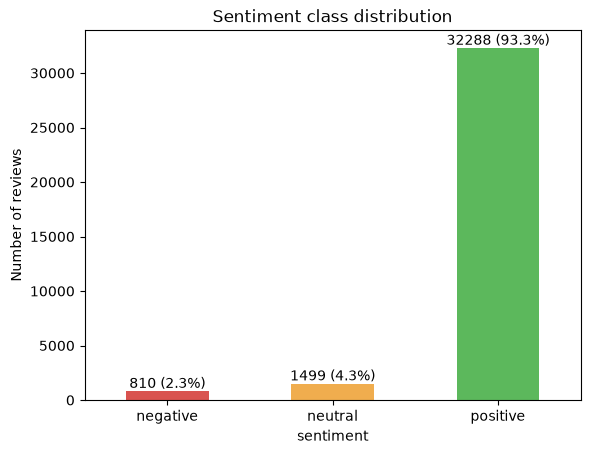

In [12]:
print(df["rating"].value_counts().sort_index())
print()
print(df["sentiment"].value_counts(normalize=True).round(3))

order = ["negative", "neutral", "positive"]
counts = df["sentiment"].value_counts().reindex(order)
ax = counts.plot(kind="bar", color=["#d9534f", "#f0ad4e", "#5cb85c"], rot=0)
ax.set_title("Sentiment class distribution")
ax.set_ylabel("Number of reviews")
for i, v in enumerate(counts):
    ax.text(i, v, f"{v} ({v / len(df):.1%})", ha="center", va="bottom")
plt.show()

**Takeaway:** the data is heavily skewed toward positive reviews. A model that always predicts "positive" would score about 93% accuracy while being useless. For this reason we will:
- use **macro-F1** and per-class recall as headline metrics, not accuracy alone,
- use **stratified** train/validation/test splits,
- use **class weights** during training.

### Review length
We need this to choose `max_length` for the transformer tokenizer.

count    34597.0
mean        33.7
std         34.5
min          3.0
25%         17.0
50%         24.0
75%         39.0
max       1868.0
Name: n_words, dtype: float64
95th percentile: 84 words


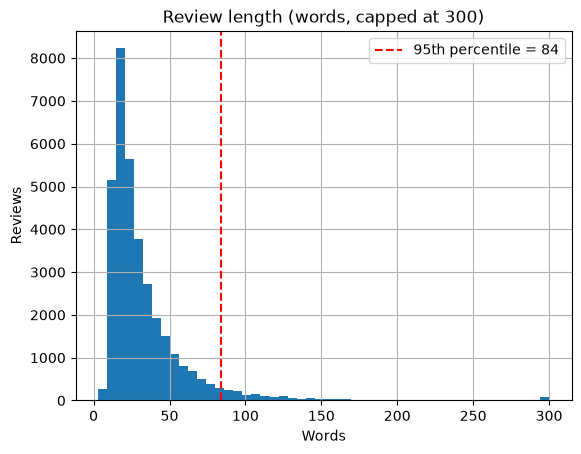

In [13]:
df["n_words"] = df["text"].str.split().str.len()
print(df["n_words"].describe().round(1))
p95 = int(df["n_words"].quantile(0.95))
print("95th percentile:", p95, "words")

df["n_words"].clip(upper=300).hist(bins=50)
plt.axvline(p95, color="red", linestyle="--", label=f"95th percentile = {p95}")
plt.title("Review length (words, capped at 300)")
plt.xlabel("Words")
plt.ylabel("Reviews")
plt.legend()
plt.show()

Most reviews are short (median around 24 words), so a `max_length` of 128 tokens covers nearly all of them and keeps transformer training fast.

### A quick look at the neutral class
Neutral is the hardest class, so it helps to read a few examples now.

In [14]:
for t in df[df["sentiment"] == "neutral"]["text"].sample(3, random_state=1):
    print("-", t, "\n")

- Okay Tablet. The specs are good, feels solid, can't stand the OS. Too many ads you can't get rid of, not as customizable as I'd like. If that doesn't bother you, it's a good tablet for the price. Don't expect to run games on it, not powerful enough for that 

- Usable 8" tablet, but I wish it were real Android. As a low priced 8" tablet, it has a good display, good speed, and reasonable battery life.I am a bit peeved by the rather intrusive adds that Amazon pushes onto it.I am also unhappy that I cannot load all the apps I am used to using on my Android phone. Overall, I wish I had spent more for a real Android device rather than having this with the Amazon limited version of Android 

- It's the thing to have, to go along with the crowd. It's the thing to have, to go along with the crowd, but it ends up being very much underutilized. I'm sure it's capable of more than making a shopping list and doing a flash briefing. But we don't have the time to learn. Other than that, it works ju

These are typically **mixed reviews**, with praise and complaints in the same text. We should expect the models to confuse neutral with its neighbours, and this will be a good topic for the error analysis.

## 9. Save the cleaned dataset

In [15]:
df[["product", "rating", "sentiment", "label", "text"]].to_csv(OUT, index=False)
print(f"Saved {len(df)} rows to {OUT}")

Saved 34597 rows to reviews_clean.csv


## Summary

| Step | What we did | Why |
|---|---|---|
| 1-2 | Loaded the data, kept 4 columns | Only rating and text matter for the task |
| 3 | Dropped rows with missing/invalid rating or text | No label or no input |
| 4 | Removed HTML, URLs and extra whitespace, but kept case and punctuation | Remove noise, keep sentiment signal for transformers |
| 5 | Combined title and body | Titles often summarise the sentiment |
| 6 | Dropped very short and duplicate reviews, checked for label conflicts | Avoid weak examples and train/test leakage |
| 7 | Mapped stars to negative / neutral / positive | The task's class definition |
| 8 | Checked class balance and length | Decide metrics, class weights and `max_length` |
| 9 | Saved `reviews_clean.csv` | Input for the modeling notebooks |

**Next:** stratified train/validation/test split, TF-IDF + Logistic Regression baseline, then fine-tuning RoBERTa.